In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType

spark = SparkSession.builder.appName('BankNotebook').getOrCreate()
bankdf = spark.read.csv('bank.csv', header = True, inferSchema = True)
bankdf.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



Input variables: age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome.

Output variable: **deposit**

In [2]:
bankdf.show(3)

+---+----------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
|age|       job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|deposit|
+---+----------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
| 59|    admin.|married|secondary|     no|   2343|    yes|  no|unknown|  5|  may|    1042|       1|   -1|       0| unknown|    yes|
| 56|    admin.|married|secondary|     no|     45|     no|  no|unknown|  5|  may|    1467|       1|   -1|       0| unknown|    yes|
| 41|technician|married|secondary|     no|   1270|    yes|  no|unknown|  5|  may|    1389|       1|   -1|       0| unknown|    yes|
+---+----------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
only showing top 3 rows



In [4]:
import pandas as pd
pd.DataFrame(bankdf.take(5), columns=bankdf.columns).transpose()

,0,1,2,3,4
age,59,56,41,55,54
job,admin.,admin.,technician,services,admin.
marital,married,married,married,married,married
education,secondary,secondary,secondary,secondary,tertiary
default,no,no,no,no,no
balance,2343,45,1270,2476,184
housing,yes,no,yes,yes,no
loan,no,no,no,no,no
contact,unknown,unknown,unknown,unknown,unknown
day,5,5,5,5,5


In [5]:
bankdf.groupby('deposit').count().show()

+-------+-----+
|deposit|count|
+-------+-----+
|     no| 5873|
|    yes| 5289|
+-------+-----+



In [6]:
numeric_features = [t[0] for t in bankdf.dtypes if t[1] == 'int']

In [7]:
numeric_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [8]:
bankdf.dtypes

[('age', 'int'),
 ('job', 'string'),
 ('marital', 'string'),
 ('education', 'string'),
 ('default', 'string'),
 ('balance', 'int'),
 ('housing', 'string'),
 ('loan', 'string'),
 ('contact', 'string'),
 ('day', 'int'),
 ('month', 'string'),
 ('duration', 'int'),
 ('campaign', 'int'),
 ('pdays', 'int'),
 ('previous', 'int'),
 ('poutcome', 'string'),
 ('deposit', 'string')]

In [9]:
bankdf.select(numeric_features).describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
age,11162,41.231947679627304,11.913369192215518,18,95
balance,11162,1528.5385235620856,3225.413325946149,-6847,81204
day,11162,15.658036194230425,8.420739541006462,1,31
duration,11162,371.99381831213043,347.12838571630687,2,3881
campaign,11162,2.508421429851281,2.7220771816614824,1,63
pdays,11162,51.33040673714388,108.75828197197717,-1,854
previous,11162,0.8325568894463358,2.292007218670508,0,58


In [10]:
numeric_data = bankdf.select(numeric_features).toPandas()

In [11]:
type(numeric_data)

pandas.core.frame.DataFrame

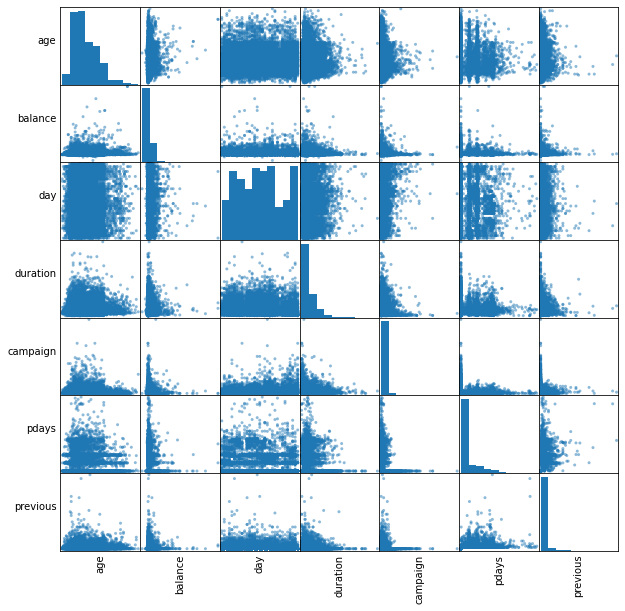

In [15]:
axs = pd.plotting.scatter_matrix(numeric_data, figsize=(10,10))
n = len(numeric_data.columns)

for i in range(n):
    v = axs[i, 0]
    v.yaxis.label.set_rotation(0)
    v.yaxis.label.set_ha('right')
    v.set_yticks(())
    h = axs[n-1, i]
    h.xaxis.label.set_rotation(90)
    h.set_xticks(())

In [16]:
df = bankdf.select('age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit')

In [18]:
cols = df.columns
cols

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

In [19]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [20]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler

In [22]:
categorical_columns = ['job', 'marital','education','default','housing','loan','contact', 'poutcome']

In [23]:
stages = []

for categoricalCol in categorical_columns:
    stringIndexer = StringIndexer(inputCol=categoricalCol, outputCol=categoricalCol + '-index')
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + 'classVec'])
    stages += [stringIndexer, encoder]

label_stringIdx = StringIndexer(inputCol='deposit', outputCol='label')
stages += [label_stringIdx]

numericCols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

assemberInputs = [c + "classVec" for c in categorical_columns] + numericCols
assembler = VectorAssembler(inputCols=assemberInputs, outputCol='features')

stages += [assembler]



In [24]:
len(stages)

18

In [25]:
for s in stages:
    print(s)

StringIndexer_035e152c69a0
OneHotEncoder_69a503fe198d
StringIndexer_bb6cb7d7d166
OneHotEncoder_3f75899b2d2e
StringIndexer_7217288b80ed
OneHotEncoder_b79e16670af4
StringIndexer_402895a21ebf
OneHotEncoder_2159fafdb81e
StringIndexer_c849732de536
OneHotEncoder_c8acd7c70778
StringIndexer_5def3479064e
OneHotEncoder_b9d7d41dba81
StringIndexer_01a7ffda5561
OneHotEncoder_9da964030616
StringIndexer_fbac4f01293c
OneHotEncoder_863b4f09f8bd
StringIndexer_aecaad628ee2
VectorAssembler_6412123962d1


In [26]:
from pyspark.ml import Pipeline

In [27]:
pipeline = Pipeline(stages=stages)
pipelineModel = pipeline.fit(df)

df = pipelineModel.transform(df)

In [28]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)
 |-- job-index: double (nullable = false)
 |-- jobclassVec: vector (nullable = true)
 |-- marital-index: double (nullable = false)
 |-- maritalclassVec: vector (nullable = true)
 |-- education-index: double (nullable = false)
 |-- educationclassVec: vector (nullable = true)
 |-- default-index: double (nullable = false)
 |-- defaultclassVec: vector (nullable = true)
 |-- housing-index: double (nullable = fals

In [29]:
pd.DataFrame(df.take(3), columns=df.columns).transpose()

,0,1,2
age,59,56,41
job,admin.,admin.,technician
marital,married,married,married
education,secondary,secondary,secondary
default,no,no,no
balance,2343,45,1270
housing,yes,no,yes
loan,no,no,no
contact,unknown,unknown,unknown
duration,1042,1467,1389


In [30]:
train, test = df.randomSplit([0.7, 0.3], seed=123)

In [32]:
test.count()

3437

In [33]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)
lrModel = lr.fit(train)

In [35]:
import matplotlib.pyplot as plt

In [37]:
trainingSummary = lrModel.summary

In [39]:
roc = trainingSummary.roc.toPandas()

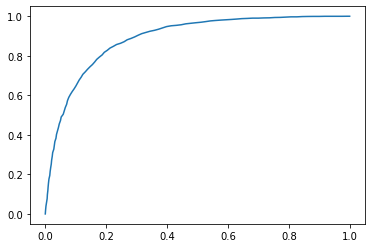

In [40]:
plt.plot(roc['FPR'], roc['TPR'])
plt.show()

In [41]:
trainingSummary.areaUnderROC

0.8877710187715938

In [42]:
pr = trainingSummary.pr.toPandas()

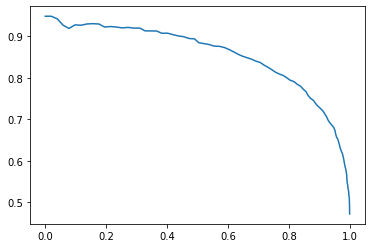

In [43]:
plt.plot(pr['recall'], pr['precision'])
plt.show()

In [44]:
preditions = lrModel.transform(test)

In [45]:
preditions.select('age', 'job', 'label', 'rawPrediction', 'prediction', 'probability').show(5)

+---+-------+-----+--------------------+----------+--------------------+
|age|    job|label|       rawPrediction|prediction|         probability|
+---+-------+-----+--------------------+----------+--------------------+
| 18|student|  0.0|[-0.1839449816108...|       1.0|[0.45414298231236...|
| 18|student|  1.0|[-0.6943390005604...|       1.0|[0.33306853707393...|
| 19|student|  1.0|[-0.6407658966245...|       1.0|[0.34507342794168...|
| 19|student|  1.0|[-0.6643012992137...|       1.0|[0.33977404727084...|
| 19|student|  1.0|[-3.2071182848973...|       1.0|[0.03889872611402...|
+---+-------+-----+--------------------+----------+--------------------+
only showing top 5 rows



In [47]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator()
evaluator.evaluate(preditions)

0.8808793789106508

In [48]:
from pyspark.ml.classification import RandomForestClassifier

In [49]:
rf = RandomForestClassifier(featuresCol='features', labelCol='label')
rfmodel = rf.fit(train)
pred = rfmodel.transform(test)

evaluator = BinaryClassificationEvaluator()
evaluator.evaluate(pred)

0.8721826350149959

In [50]:
from pyspark.ml.classification import GBTClassifier  # Gradient-Boost Tree Classifier

gbt = GBTClassifier(maxIter=10)
gbtModel = gbt.fit(train)
pred = gbtModel.transform(test)

evaluator = BinaryClassificationEvaluator()
evaluator.evaluate(pred)

0.8849793694097207

In [52]:
print(gbt.explainParams())

cacheNodeIds: If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval. (default: False)
checkpointInterval: set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext. (default: 10)
featureSubsetStrategy: The number of features to consider for splits at each tree node. Supported options: 'auto' (choose automatically for task: If numTrees == 1, set to 'all'. If numTrees > 1 (forest), set to 'sqrt' for classification and to 'onethird' for regression), 'all' (use all features), 'onethird' (use 1/3 of the features), 'sqrt' (use sqrt(number of features)), 'log2' (use log2(number of features)), 

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

paramGrid = (ParamGridBuilder()
             .addGrid(gbt.maxDepth, [2,3,4])
             .addGrid(gbt.maxBins, [20, 50])
             .addGrid(gbt.maxIter, [10, 20])
            ).build()

cv = CrossValidator(estimator=gbt, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=5)
cvmodel = cv.fit(train)
pred = cvmodel.transform(test)
evaluator.evaluate(pred)